In [1]:
!pip install scrapy crochet -q

import scrapy
from scrapy.crawler import CrawlerRunner
import pandas as pd
from crochet import setup, wait_for

setup()
scraped_books = []
class BooksSpider(scrapy.Spider):
    name = "books_spider"
    allowed_domains = ["books.toscrape.com"]
    start_urls = ["https://books.toscrape.com/catalogue/page-1.html"]
    page_count = 1
    max_pages = 5
    custom_settings = {
        'LOG_LEVEL': 'ERROR',
        'CONCURRENT_REQUESTS': 8,
        'DOWNLOAD_DELAY': 0.1,
        'TWISTED_REACTOR': 'twisted.internet.epollreactor.EPollReactor'
    }

    def parse(self, response):
        book_links = response.css("article.product_pod h3 a::attr(href)").getall()
        for link in book_links:
            yield response.follow(link, callback=self.parse_book)
        self.page_count += 1
        if self.page_count <= self.max_pages:
            next_page = response.css("li.next a::attr(href)").get()
            if next_page:
                yield response.follow(next_page, callback=self.parse)
    def parse_book(self, response):
        title = response.css("div.product_main h1::text").get("").strip()
        category = response.css("ul.breadcrumb li:nth-child(3) a::text").get("").strip()
        price = response.css("p.price_color::text").get("").strip()
        rating_classes = response.css("p.star-rating::attr(class)").get("").split()
        rating = rating_classes[1] if len(rating_classes) > 1 else ""
        availability = " ".join(response.css("p.availability::text").getall()).strip()
        description = response.css("div#product_description + p::text").get("").strip()

        table_rows = response.css("table.table-striped tr")
        product_info = {}
        for row in table_rows:
            key = row.css("th::text").get("").strip()
            val = row.css("td::text").get("").strip()
            product_info[key] = val

        book_item = {
            "Title": title,
            "Category": category,
            "Price": price,
            "Rating": rating,
            "Availability": availability,
            "Product Description": description,
            "UPC": product_info.get("UPC", ""),
            "Number of Reviews": product_info.get("Number of reviews", ""),
            "Product URL": response.url
        }

        scraped_books.append(book_item)
        yield book_item

@wait_for(timeout=60.0)
def run_spider():
    scraped_books.clear()
    runner = CrawlerRunner()
    return runner.crawl(BooksSpider)
run_spider()

df = pd.DataFrame(scraped_books)
df.to_csv("books_100.csv", index=False, encoding="utf-8")
df.to_json("books_100.json", orient="records", indent=4)
print("\n========== SCRAPING SUMMARY ==========")
print("Total Books Scraped :", len(df))
print("Pages Scraped       : 5")
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate UPC Values :", df["UPC"].duplicated().sum() if "UPC" in df else 0)
print("\nFiles Generated:")
print("1. books_100.csv")
print("2. books_100.json")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.4/350.4 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.4/106.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 6.5 MB/s eta 0:00:00

========== SCRAPING SUMMARY ==========
Total Books Scraped : 100
Pages Scraped       : 5

Missing Values:
Title                  0
Category               0
Price                  0
Rating                 0
Availability           0
Product Description    0
UPC                    0
Number of Reviews      0
Product URL            0
dtype: int64

Duplicate UPC Values : 0

Files Generated:
1. books_100.csv
2. books_100.json


In [2]:
import pandas as pd
import re


# Load dataset
df = pd.read_csv("books_100.csv")

# Fix encoding issues in Price
df['Price'] = df['Price'].str.replace("Â£", "£")

# Deduplicate by UPC
df = df.drop_duplicates(subset=['UPC'])

# Handle missing descriptions
df['Product Description'] = df['Product Description'].fillna("No description available")

# Convert Price to numeric
df['Price'] = df['Price'].str.replace("£", "").astype(float)

# Map Ratings to integers
rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
df['Rating'] = df['Rating'].map(rating_map)

# Extract stock count
df['Stock'] = df['Availability'].str.extract(r'(\d+)').astype(int)

# Word count of description
df['description_word_count'] = df['Product Description'].apply(lambda x: len(str(x).split()))

# Price band
df['price_band'] = pd.cut(df['Price'], bins=[0,20,40,100], labels=['Low','Medium','High'])

# Affordability score (rating/price)
df['affordability_score'] = df['Rating'] / df['Price']

# Value score (rating * reviews + stock / price)
df['value_score'] = (df['Rating'] * df['Number of Reviews'] + df['Stock']) / df['Price']

# Recommended flag
df['recommended'] = (df['Rating'] >= 4) & (df['Price'] <= 40)

# Drop Availability column
df = df.drop(columns=['Availability'])

# Save cleaned dataset
df.to_csv("books_cleaned.csv", index=False)

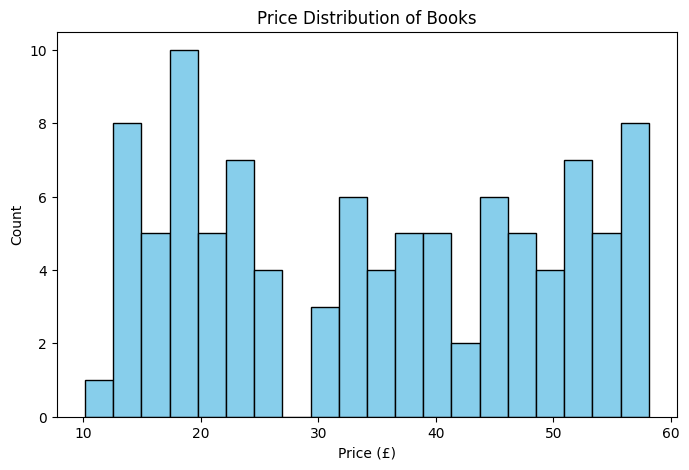

<Figure size 640x480 with 0 Axes>

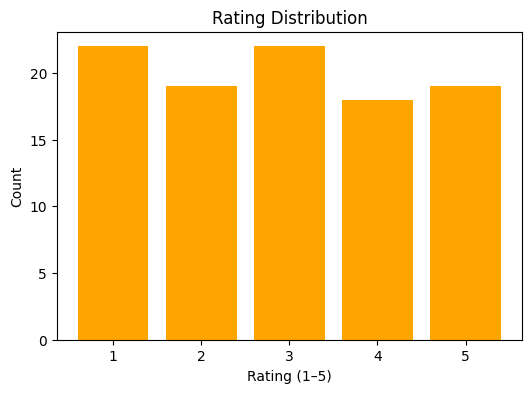

<Figure size 640x480 with 0 Axes>

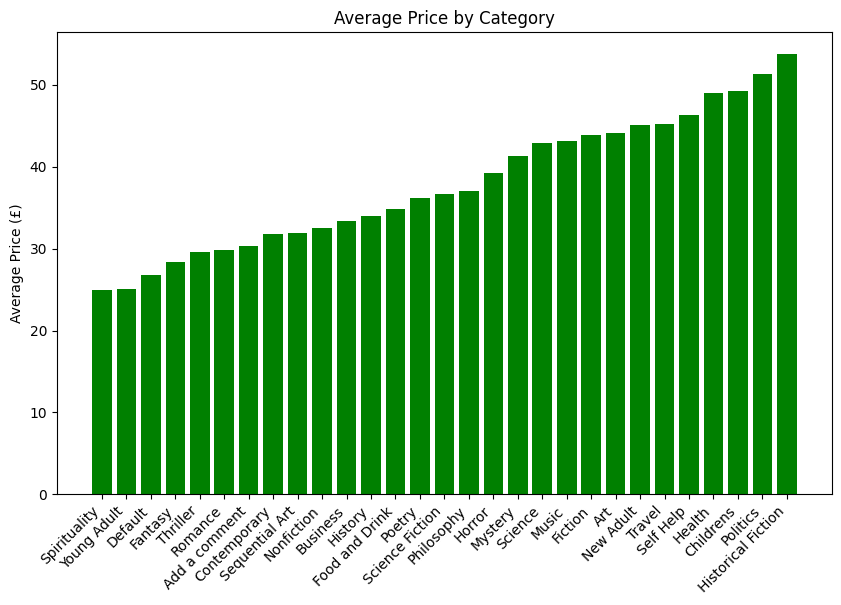

<Figure size 640x480 with 0 Axes>

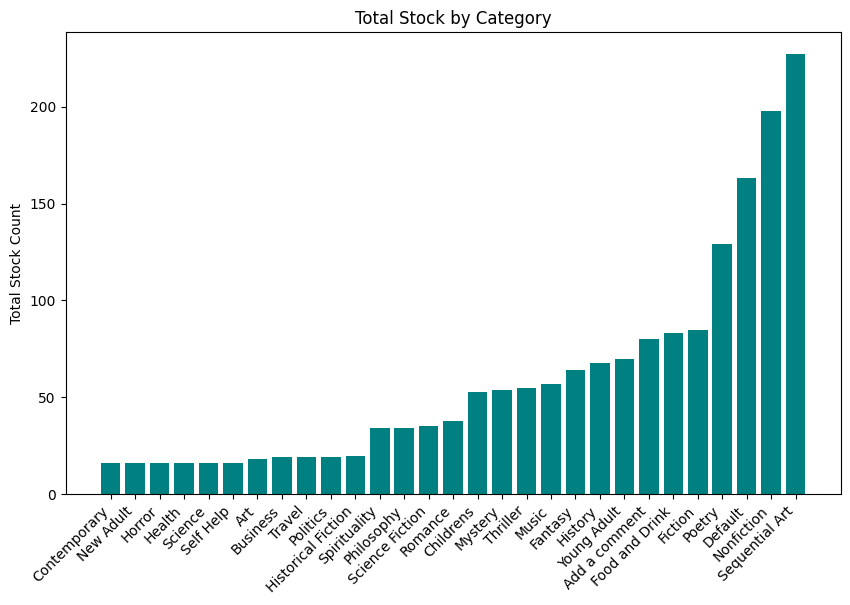

<Figure size 640x480 with 0 Axes>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Price Distribution
plt.figure(figsize=(8,5))
plt.hist(df['Price'], bins=20, color='skyblue', edgecolor='black')
plt.title("Price Distribution of Books")
plt.xlabel("Price (£)")
plt.ylabel("Count")
plt.show()
plt.savefig("price_distribution.png")

# Rating Distribution
plt.figure(figsize=(6,4))
plt.bar(df['Rating'].value_counts().index, df['Rating'].value_counts().values, color='orange')
plt.title("Rating Distribution")
plt.xlabel("Rating (1–5)")
plt.ylabel("Count")
plt.show()
plt.savefig("rating_distribution.png")

# Average Price by Category
avg_price = df.groupby('Category')['Price'].mean().sort_values()
plt.figure(figsize=(10,6))
plt.bar(avg_price.index, avg_price.values, color='green')
plt.xticks(rotation=45, ha="right")
plt.title("Average Price by Category")
plt.ylabel("Average Price (£)")
plt.show()
plt.savefig("avg_price_by_category.png")

# Total Stock by Category
total_stock = df.groupby('Category')['Stock'].sum().sort_values()

plt.figure(figsize=(10,6))
plt.bar(total_stock.index, total_stock.values, color='teal')
plt.xticks(rotation=45, ha="right")
plt.title("Total Stock by Category")
plt.ylabel("Total Stock Count")
plt.show()
plt.savefig("total_stock_by_category.png")

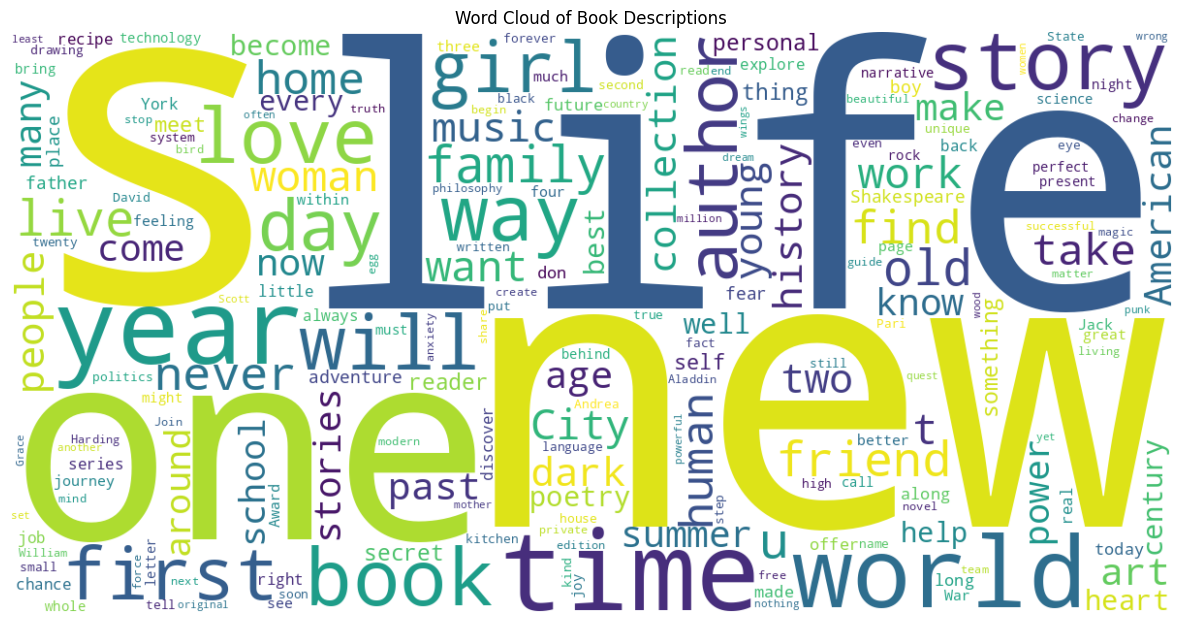

<Figure size 640x480 with 0 Axes>

In [4]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv("books_cleaned.csv")

# Combine all descriptions
text = " ".join(df["Product Description"].dropna().astype(str))

# Generate word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    collocations=False
).generate(text)

# Display
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Book Descriptions")
plt.show()
plt.savefig("wordcloud.png")